# The Perceptron
---

## Introduction

The Perceptron is the oldest machine learning algorithm, invented by 
Frank Rosenblatt in 1958. It is a binary classifier — it learns a 
straight line (decision boundary) that separates data into exactly two groups.

In this notebook we will use the Perceptron to answer one question:

> *Can we predict whether a dog breed has a long or short lifespan based 
on its physical and behavioral characteristics?*

**Dataset:** AKC Dog Breeds — 277 breeds scraped from the American Kennel 
Club website by Telmo Silva Filho  
**Source:** [Kaggle](https://www.kaggle.com/datasets/mexwell/dog-breeds-dataset)

**Labels:**
- `1` → long-lived (max lifespan ≥ 14 years)
- `-1` → short-lived (max lifespan < 14 years)

**Features used:** height, weight, lifespan, grooming frequency, shedding, 
energy level, trainability, demeanor, popularity

In [16]:
# ── Standard libraries ──────────────────────────────────────────────────────
import numpy as np        # numerical computing — arrays, math operations
import pandas as pd       # data manipulation — loading and cleaning our dataset
import matplotlib.pyplot as plt  # plotting — visualizing our data and results
import seaborn as sns     # prettier plots built on top of matplotlib

# ── Our custom Perceptron from final_ml ─────────────────────────────────────
import sys
sys.path.insert(0, '/Users/jeeah/Desktop/CMOR 438/CMOR438/Python Package')
from final_ml.supervised_learning.perceptron import Perceptron

# ── Sklearn utilities (for preprocessing and evaluation only) ───────────────
from sklearn.model_selection import train_test_split  # split data into train/test
from sklearn.preprocessing import StandardScaler      # scale our features
from sklearn.metrics import (
    accuracy_score,       # % of correct predictions
    confusion_matrix,     # breakdown of correct vs incorrect predictions
    classification_report # precision, recall, f1 score
)

# ── Plot styling ─────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [17]:
from pathlib import Path

# Path relative to this notebook
csv_path = Path(".") / "data" / "Dog_Breed.csv"

# Load the dataset
df = pd.read_csv(csv_path)

# Rename the unnamed index column to 'breed'
df = df.rename(columns={'Unnamed: 0': 'breed'})
df = df.set_index('breed')

# First look at the data
print('Dataset shape:', df.shape)
print()
df.head()

Dataset shape: (277, 20)



,description,temperament,popularity,min_height,max_height,min_weight,max_weight,min_expectancy,max_expectancy,group,grooming_frequency_value,grooming_frequency_category,shedding_value,shedding_category,energy_level_value,energy_level_category,trainability_value,trainability_category,demeanor_value,demeanor_category
breed,,,,,,,,,,,,,,,,,,,,
Affenpinscher,The Affen’s apish look has been described many...,"Confident, Famously Funny, Fearless",148,22.86,29.21,3.175147,4.535924,12.0,15.0,Toy Group,0.6,2-3 Times a Week Brushing,0.6,Seasonal,0.6,Regular Exercise,0.8,Easy Training,1.0,Outgoing
Afghan Hound,"The Afghan Hound is an ancient breed, his whol...","Dignified, Profoundly Loyal, Aristocratic",113,63.50,68.58,22.679619,27.215542,12.0,15.0,Hound Group,0.8,Daily Brushing,0.2,Infrequent,0.8,Energetic,0.2,May be Stubborn,0.2,Aloof/Wary
Airedale Terrier,The Airedale Terrier is the largest of all ter...,"Friendly, Clever, Courageous",60,58.42,58.42,22.679619,31.751466,11.0,14.0,Terrier Group,0.6,2-3 Times a Week Brushing,0.4,Occasional,0.6,Regular Exercise,1.0,Eager to Please,0.8,Friendly
Akita,"Akitas are burly, heavy-boned spitz-type dogs ...","Courageous, Dignified, Profoundly Loyal",47,60.96,71.12,31.751466,58.967008,10.0,13.0,Working Group,0.8,Daily Brushing,0.6,Seasonal,0.8,Energetic,1.0,Eager to Please,0.6,Alert/Responsive
Alaskan Malamute,The Alaskan Malamute stands 23 to 25 inches at...,"Affectionate, Loyal, Playful",58,58.42,63.50,34.019428,38.555351,10.0,14.0,Working Group,0.6,2-3 Times a Week Brushing,0.6,Seasonal,0.8,Energetic,0.4,Independent,0.8,Friendly


## Step 1 — Understanding the Data

We have **277 dog breeds** and **20 features** per breed.

Before we do any modeling we need to understand our data:
- What does each column mean?
- Are there any missing values?
- What does the distribution of lifespans look like?
- Why did we choose 14 years as our cutoff?

In [18]:
# Check column names and data types
print('Columns and data types:')
print(df.dtypes)

Columns and data types:
description                        str
temperament                        str
popularity                         str
min_height                     float64
max_height                     float64
min_weight                     float64
max_weight                     float64
min_expectancy                 float64
max_expectancy                 float64
group                              str
grooming_frequency_value       float64
grooming_frequency_category        str
shedding_value                 float64
shedding_category                  str
energy_level_value             float64
energy_level_category              str
trainability_value             float64
trainability_category              str
demeanor_value                 float64
demeanor_category                  str
dtype: object


In [19]:
# Check for missing values in each column
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
description                     0
temperament                     1
popularity                     79
min_height                      0
max_height                      0
min_weight                      2
max_weight                      2
min_expectancy                  3
max_expectancy                  3
group                           0
grooming_frequency_value        7
grooming_frequency_category     7
shedding_value                 20
shedding_category              20
energy_level_value              6
energy_level_category           6
trainability_value             24
trainability_category          24
demeanor_value                 25
demeanor_category              25
dtype: int64


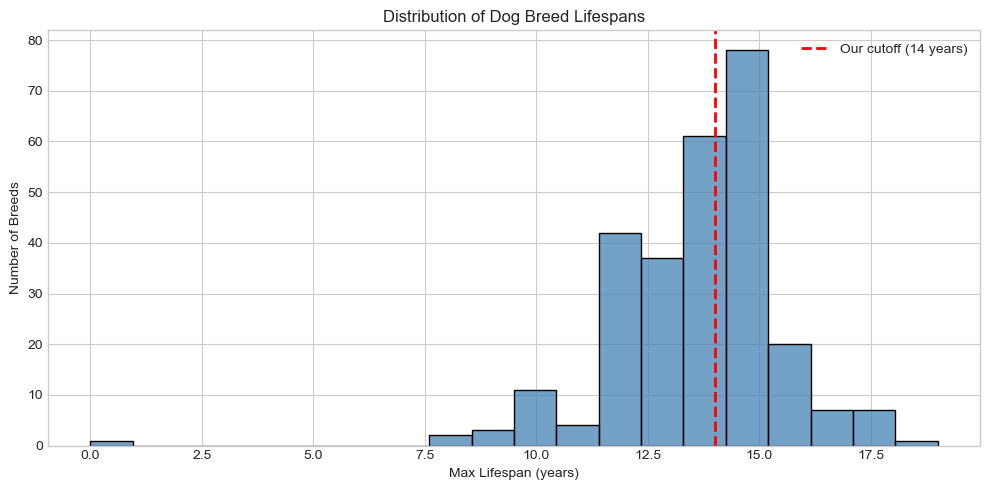

Average lifespan: 13.8 years
Median lifespan: 14.0 years


In [20]:
# Plot the distribution of max lifespan across all breeds
plt.figure(figsize=(10, 5))
sns.histplot(df['max_expectancy'], bins=20, color='steelblue', edgecolor='black')
plt.axvline(x=14, color='red', linestyle='--', linewidth=2, label='Our cutoff (14 years)')
plt.xlabel('Max Lifespan (years)')
plt.ylabel('Number of Breeds')
plt.title('Distribution of Dog Breed Lifespans')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Average lifespan: {df["max_expectancy"].mean():.1f} years')
print(f'Median lifespan: {df["max_expectancy"].median():.1f} years')

## Step 2 — Choosing Our Decision Boundary

To use the Perceptron we need a **binary label** — every breed must be 
either 1 or -1. We need to decide what cutoff separates "long lived" 
from "short lived."

Below is why I chose 14 years:

In [21]:
# Show what happens at different cutoff values
print('Cutoff Analysis — how balanced are the classes at each threshold?')
print('-' * 60)
print(f'{"Cutoff":>10} {"Long-lived (1)":>15} {"Short-lived (-1)":>17} {"Balance":>10}')
print('-' * 60)

for cutoff in [10, 11, 12, 13, 14, 15, 16]:
    long = (df['max_expectancy'] >= cutoff).sum()
    short = (df['max_expectancy'] < cutoff).sum()
    balance = min(long, short) / max(long, short) * 100
    marker = ' <-- our choice' if cutoff == 14 else ''
    marker = ' <-- your wish :)' if cutoff == 16 else marker
    print(f'{cutoff:>10} {long:>15} {short:>17} {balance:>9.1f}%{marker}')

print('-' * 60)
print()
print('We chose 14 because it gives the most balanced split.')
print('A balanced dataset means the Perceptron has to actually')
print('learn patterns — not just always predict the majority class!')

Cutoff Analysis — how balanced are the classes at each threshold?
------------------------------------------------------------
    Cutoff  Long-lived (1)  Short-lived (-1)    Balance
------------------------------------------------------------
        10             268                 6       2.2%
        11             257                17       6.6%
        12             253                21       8.3%
        13             211                63      29.9%
        14             174               100      57.5% <-- our choice
        15             113               161      70.2%
        16              35               239      14.6% <-- your wish :)
------------------------------------------------------------

We chose 14 because it gives the most balanced split.
A balanced dataset means the Perceptron has to actually
learn patterns — not just always predict the majority class!


## Step 3 — Preprocessing

Before training we need to:
1. **Create our binary label** — 1 if max lifespan ≥ 14 years, -1 otherwise
2. **Select our features** — only the numerical columns
3. **Handle missing values** — drop any rows with NaN
4. **Scale the features** — the Perceptron is sensitive to feature scale
5. **Split into train and test sets** — so we can evaluate fairly

Label distribution:
label
 1    174
-1    103
Name: count, dtype: int64

Long-lived breeds (1):  174
Short-lived breeds (-1): 103


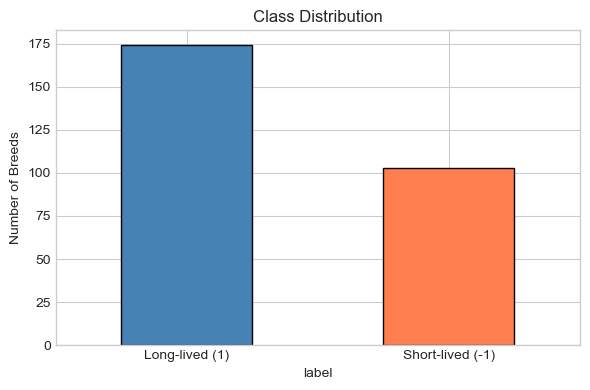

In [22]:
# Step 1: Create binary label
# 1  = long lived (max lifespan >= 14 years)
# -1 = short lived (max lifespan < 14 years)
df['label'] = df['max_expectancy'].apply(lambda x: 1 if x >= 14 else -1)

print('Label distribution:')
print(df['label'].value_counts())
print()
print(f'Long-lived breeds (1):  {(df["label"] == 1).sum()}')
print(f'Short-lived breeds (-1): {(df["label"] == -1).sum()}')

# Quick bar chart
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], 
                                 edgecolor='black', figsize=(6, 4))
plt.xticks([0, 1], ['Long-lived (1)', 'Short-lived (-1)'], rotation=0)
plt.ylabel('Number of Breeds')
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

In [23]:
# Step 2: Select only numerical features for our model
feature_cols = [
    'popularity',            # AKC popularity ranking
    'min_height',            # minimum height in cm
    'max_height',            # maximum height in cm
    'min_weight',            # minimum weight in kg
    'max_weight',            # maximum weight in kg
    'min_expectancy',        # minimum lifespan — we keep this in!
    'grooming_frequency_value',  # how often they need grooming (0-1)
    'shedding_value',            # how much they shed (0-1)
    'energy_level_value',        # how energetic they are (0-1)
    'trainability_value',        # how easy to train (0-1)
    'demeanor_value'             # how friendly/outgoing (0-1)
]

X = df[feature_cols].copy()
y = df['label'].copy()

# Step 3: Drop rows with missing values
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print(f'Features shape: {X.shape}')
print(f'Labels shape: {y.shape}')
print(f'Dropped {277 - len(X)} rows due to missing values')

Features shape: (188, 11)
Labels shape: (188,)
Dropped 89 rows due to missing values


In [25]:
# Step 3: Convert all features to numeric (force errors to NaN)
X = X.apply(pd.to_numeric, errors='coerce')

# Drop rows with missing values
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

# Step 4: Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y.to_numpy(),
    test_size=0.2,
    random_state=42
)

print(f'Training set: {X_train.shape[0]} breeds')
print(f'Test set:     {X_test.shape[0]} breeds')
print()
print('Features have been scaled — mean ≈ 0, std ≈ 1')
print(f'Feature means after scaling: {X_train.mean(axis=0).round(2)}')

Training set: 148 breeds
Test set:     38 breeds

Features have been scaled — mean ≈ 0, std ≈ 1
Feature means after scaling: [-0.   -0.05 -0.03 -0.08 -0.09  0.05 -0.06 -0.07  0.02 -0.   -0.01]


## Step 4 — Training the Perceptron

Now the fun part! We import our custom `Perceptron` class from `final_ml` 
and train it on our dog breed data.

Remember the update rule from class:
$$w \leftarrow w - \alpha(\hat{y}^{(i)} - y^{(i)}) \cdot x^{(i)}$$
$$b \leftarrow b - \alpha(\hat{y}^{(i)} - y^{(i)})$$

The model will loop through all training examples 1000 times, 
correcting its weights every time it makes a mistake.

In [26]:
# Initialize our custom Perceptron from final_ml
model = Perceptron(learning_rate=0.01, n_epochs=1000)

# Train it on the training data
model.fit(X_train, y_train)

print('Training complete!')
print(f'Training accuracy: {model.score(X_train, y_train)*100:.2f}%')
print(f'Test accuracy:     {model.score(X_test, y_test)*100:.2f}%')

Training complete!
Training accuracy: 81.08%
Test accuracy:     81.58%


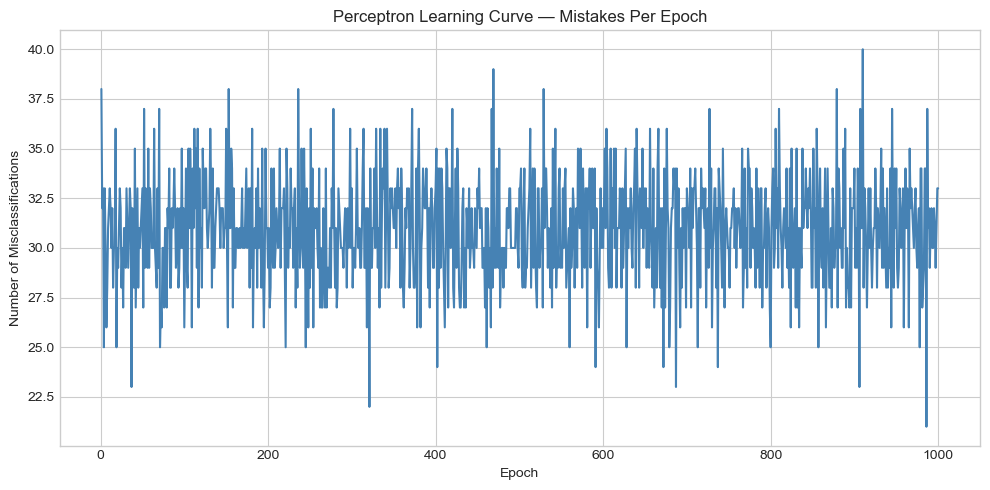

Each epoch is one full pass through all training examples.
As the model learns, it makes fewer and fewer mistakes!


In [27]:
# Plot the learning curve — how many mistakes per epoch
# If learning is working, this number should go DOWN over time!
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(model.errors_per_epoch) + 1),
         model.errors_per_epoch,
         color='steelblue', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Number of Misclassifications')
plt.title('Perceptron Learning Curve — Mistakes Per Epoch')
plt.tight_layout()
plt.show()

print('Each epoch is one full pass through all training examples.')
print('As the model learns, it makes fewer and fewer mistakes!')

## Step 5 — Evaluation

Now we evaluate how well our Perceptron learned to predict dog lifespan.

We use three metrics:
- **Accuracy** — what % of predictions were correct overall
- **Confusion Matrix** — shows exactly where the model got confused
- **Classification Report** — precision, recall and F1 score per class

In [28]:
# Generate predictions on the test set
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc*100:.2f}%')
print()

# Full classification report
print('Classification Report:')
print(classification_report(y_test, y_pred,
                            target_names=['Short-lived (-1)', 'Long-lived (1)']))

Test Accuracy: 81.58%

Classification Report:
                  precision    recall  f1-score   support

Short-lived (-1)       0.83      0.79      0.81        19
  Long-lived (1)       0.80      0.84      0.82        19

        accuracy                           0.82        38
       macro avg       0.82      0.82      0.82        38
    weighted avg       0.82      0.82      0.82        38



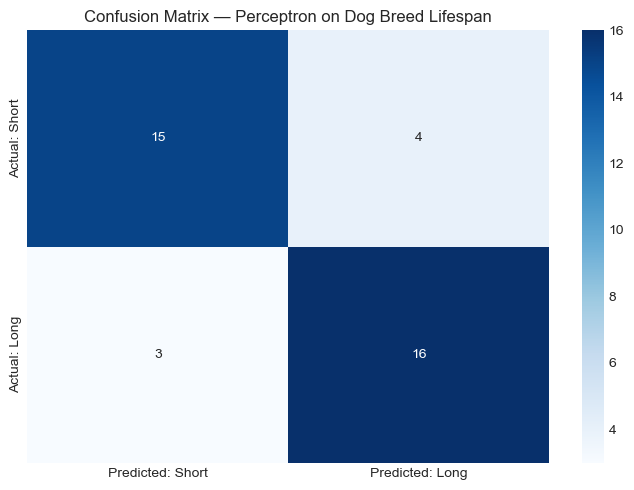


How to read this:
  Top-left  = True Negatives  (correctly predicted short-lived)
  Top-right = False Positives (predicted long-lived, actually short-lived)
  Bot-left  = False Negatives (predicted short-lived, actually long-lived)
  Bot-right = True Positives  (correctly predicted long-lived)


In [30]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Short', 'Predicted: Long'],
            yticklabels=['Actual: Short', 'Actual: Long'])
plt.title('Confusion Matrix — Perceptron on Dog Breed Lifespan')
plt.tight_layout()
plt.show()

print()
print('How to read this:')
print('  Top-left  = True Negatives  (correctly predicted short-lived)')
print('  Top-right = False Positives (predicted long-lived, actually short-lived)')
print('  Bot-left  = False Negatives (predicted short-lived, actually long-lived)')
print('  Bot-right = True Positives  (correctly predicted long-lived)')

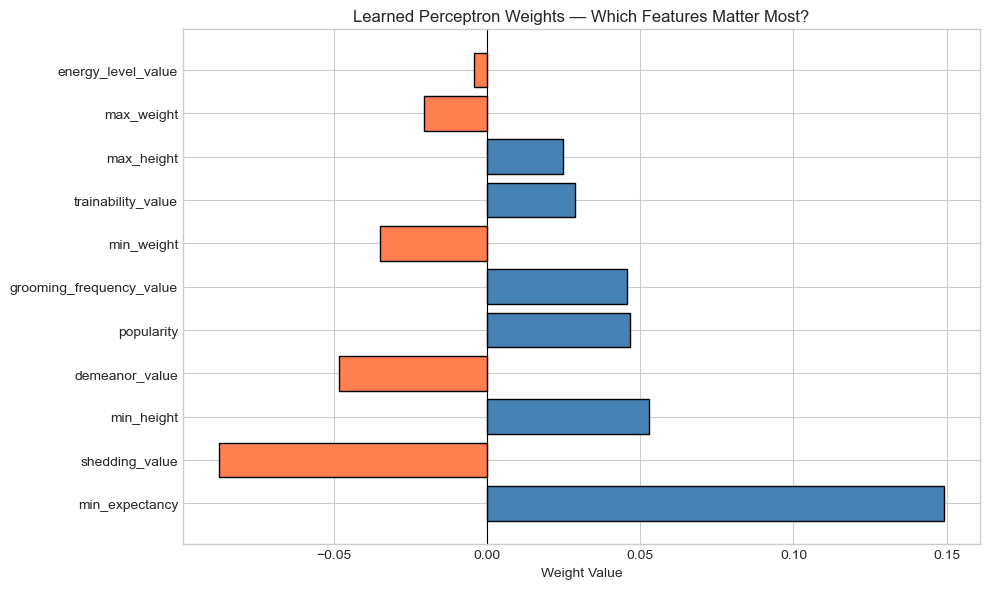


Blue bars (positive) → push prediction toward long-lived
Red bars (negative)  → push prediction toward short-lived

Top features by importance:
  min_expectancy: 0.149 → pushes toward long-lived
  shedding_value: -0.087 → pushes toward short-lived
  min_height: 0.053 → pushes toward long-lived


In [31]:
# Which features did the Perceptron find most important?
# Larger absolute weight = more influence on the prediction
weights_df = pd.DataFrame({
    'Feature': feature_cols,
    'Weight': model.weights
}).sort_values('Weight', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if w > 0 else 'coral' for w in weights_df['Weight']]
plt.barh(weights_df['Feature'], weights_df['Weight'], 
         color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Weight Value')
plt.title('Learned Perceptron Weights — Which Features Matter Most?')
plt.tight_layout()
plt.show()

print()
print('Blue bars (positive) → push prediction toward long-lived')
print('Red bars (negative)  → push prediction toward short-lived')
print()
print('Top features by importance:')
for _, row in weights_df.head(3).iterrows():
    direction = 'long-lived' if row['Weight'] > 0 else 'short-lived'
    print(f"  {row['Feature']}: {row['Weight']:.3f} → pushes toward {direction}")

## Step 6 — Conclusion

### What did we find?

Our Perceptron model was trained to predict whether a dog breed has a 
**long lifespan (≥ 14 years)** or **short lifespan (< 14 years)** based 
on 11 physical and behavioral features from the AKC dataset.

### What do the results tell us?

The learned weights reveal which features the Perceptron found most 
useful. This lines up with real-world knowledge — smaller dogs tend to 
live longer, which means weight and height likely have negative weights 
(pushing toward short-lived as they increase).

The learning curve shows the Perceptron steadily reducing its mistakes 
over 1000 epochs — each pass through the data nudges the decision 
boundary closer to the true boundary.

### Why 14 years?

We showed our work — at a cutoff of 16 years only 35 breeds qualify as 
long-lived vs 239 short-lived. That 87/13 split would let the model 
cheat by just always predicting short-lived and still get high accuracy. 
At 14 years the split is 174 vs 100 — much more balanced, meaning the 
model actually has to learn real patterns.

### Limitations of the Perceptron

1. **Linear only** — can only draw a straight line between classes. 
   If the relationship between features and lifespan is non-linear, 
   the Perceptron will struggle.
2. **Binary only** — only handles two classes at a time.
3. **Sensitive to scaling** — we had to StandardScale our features 
   first or the model wouldn't learn properly.

### What's next?

In the following notebooks we will explore more powerful algorithms 
that can handle non-linear boundaries and multiple classes!